#Data Keuangan



##Sumber Data
Dataset dari kaggle (personal-finance-tracker-dataset) : https://www.kaggle.com/datasets/khushikyad001/personal-finance-tracker-dataset?resource=download
<br>



#import Libarary

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

#LOAD DATA

In [ ]:
data_df = pd.read_csv('raw data keuangan.csv')
data_df.head()

,date,user_id,monthly_income,monthly_expense_total,savings_rate,budget_goal,financial_scenario,credit_score,debt_to_income_ratio,loan_payment,...,discretionary_spending,essential_spending,income_type,rent_or_mortgage,category,cash_flow_status,financial_advice_score,financial_stress_level,actual_savings,savings_goal_met
0,2019-01-01,1584,3119.58,3212.07,0.38,3676.11,inflation,721.0,0.56,125.77,...,857.55,1910.85,Freelance,1501.65,Investments,Positive,8.3,Low,0.00,0
1,2019-01-31,1045,3262.44,3732.81,0.10,2607.17,inflation,670.0,0.42,454.19,...,534.51,3165.20,Salary,1603.17,Investments,Positive,22.6,Low,0.00,0
2,2019-03-02,1756,2931.20,3335.58,0.15,3004.14,inflation,691.0,0.24,971.82,...,353.67,1504.56,Freelance,1097.82,Healthcare,Positive,58.8,Low,0.00,0
3,2019-04-01,1724,3506.79,2327.59,0.17,3346.97,normal,717.0,0.16,482.76,...,594.08,1450.72,Freelance,1155.64,Groceries,Positive,74.5,Low,1179.20,0
4,2019-05-01,1600,4606.87,2182.58,0.34,2670.09,inflation,795.0,0.25,263.74,...,556.86,1000.00,Salary,1170.86,Utilities,Negative,38.7,High,2424.29,0


Okey dari dataset personal finance tracker ini, tidak semua kolom akan dipakai dalam data financial treacker feature kami. Kami akan melakukan Feature Selection untuk memiilih kolom kolom yang akan di pakai pada fitur kami yaitu mengenai pemasukan, pengeluaran, dana darurat, rasion hutang/cicilan perbulan

#Feature Selection

##Kolom yang akan dipakai:
- 'Date'
- 'user_id'
- 'monthly_income'
- 'monthly_expense_total'
- 'emergency_fund',
- 'investment_amount',     
- 'debt_to_income_ratio'

In [ ]:
feature_kami = [
    'date',
    'user_id',
    'monthly_income',
    'monthly_expense_total',
    'emergency_fund',
    'investment_amount',
    'debt_to_income_ratio'
]

df_feature_kami = data_df[feature_kami].copy()

Memilih kolom yang akan dipakai, dan mengcopy data_df untuk dataframe baru (df_feature_kami)

In [ ]:
df_feature_kami.head()

,date,user_id,monthly_income,monthly_expense_total,emergency_fund,investment_amount,debt_to_income_ratio
0,2019-01-01,1584,3119.58,3212.07,510.58,689.22,0.56
1,2019-01-31,1045,3262.44,3732.81,1154.41,360.34,0.42
2,2019-03-02,1756,2931.20,3335.58,1433.02,0.00,0.24
3,2019-04-01,1724,3506.79,2327.59,227.37,182.06,0.16
4,2019-05-01,1600,4606.87,2182.58,589.81,342.78,0.25


#ASSESSING DATA

In [ ]:
df_feature_kami.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   3000 non-null   object 
 1   user_id                3000 non-null   int64  
 2   monthly_income         3000 non-null   float64
 3   monthly_expense_total  3000 non-null   float64
 4   emergency_fund         3000 non-null   float64
 5   investment_amount      3000 non-null   float64
 6   debt_to_income_ratio   3000 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 164.2+ KB


Tidak ada data yang null, dan hanya fitur 'date' yang perlu disesuaikan tipe datanya (date), dan 'user' id yang disesuaikan tipe (str)

ubah date type : (object) ke (datetime)

In [ ]:
df_feature_kami.isna().sum()

,0
date,0
user_id,0
monthly_income,0
monthly_expense_total,0
emergency_fund,0
investment_amount,0
debt_to_income_ratio,0


In [ ]:
df_feature_kami.duplicated().sum()

np.int64(0)

Tidak ada data yang duplicated

In [ ]:
df_feature_kami.describe()

,user_id,monthly_income,monthly_expense_total,emergency_fund,investment_amount,debt_to_income_ratio
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1498.699000,4004.267347,3011.682230,1005.349830,400.610493,0.350817
std,287.352782,1000.107096,801.151864,485.780881,235.361273,0.145191
min,1000.000000,685.280000,159.210000,0.000000,0.000000,0.100000
25%,1248.750000,3362.250000,2473.205000,674.012500,234.780000,0.220000
50%,1496.500000,4008.075000,3023.810000,1010.485000,388.075000,0.350000
75%,1749.000000,4659.040000,3555.502500,1337.820000,559.842500,0.480000
max,1999.000000,7407.940000,5853.200000,2585.360000,1292.300000,0.600000


Hasil dari regresi masing masing fitur terlihat aman

#DATA CLEANING & REPROCESSING

In [ ]:
df_clean_data = df_feature_kami.copy()

Mengcopy df_featur_kami untuk dataframe df_clean_data

In [ ]:
df_clean_data['date'] = pd.to_datetime(df_clean_data['date'])

Mengsetting tipe data fitur 'date' menjadi (date)

In [ ]:
df_clean_data['user_id'] = df_clean_data['user_id'].astype(str)

Dan juga mensetting tipe data 'user_id' menjadi str

In [ ]:
df_clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   3000 non-null   datetime64[ns]
 1   user_id                3000 non-null   object        
 2   monthly_income         3000 non-null   float64       
 3   monthly_expense_total  3000 non-null   float64       
 4   emergency_fund         3000 non-null   float64       
 5   investment_amount      3000 non-null   float64       
 6   debt_to_income_ratio   3000 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 164.2+ KB


Okey, data sudah bersih

#FEATURE ENGINEERING

In [ ]:
df_keuangan = df_clean_data.copy()

Mencopy dataframe df_clean_data untuk dataframe baru df_keuangan

In [ ]:
np.random.seed(42)
df_keuangan['age'] = np.random.randint(18, 31, size=len(df_keuangan))

Membuat fitur baru 'age' di mana mengkunci random terlebih dahulu agar setiap di run tidak perlu mengack kembali, dan range pengambilan value acak nya rentan 18-31

##Menkonversi value fitur 'monthly_income', 'monthly_expense_total' 'investment_amount', 'emergency_fund' dalam rupiah (IDR)

In [ ]:
KURS_USD_TO_IDR = 17478

Menetapkan variabel kurs USD to Rupiah (IDR)

In [ ]:
kolom_uang = [
    'monthly_income',
    'monthly_expense_total',
    'investment_amount',
    'emergency_fund',
]

Memilih fitur yang akan dikonversi

In [ ]:
for col in kolom_uang:
    if col in df_keuangan.columns:
        df_keuangan[col] = df_keuangan[col] * KURS_USD_TO_IDR

Melakukan pengulangan pada kolom uang untuk mengalikan value pada masing masing fitur dengan KURS_USD_TO_IDR

In [ ]:
df_keuangan.head(21)

,date,user_id,monthly_income,monthly_expense_total,emergency_fund,investment_amount,debt_to_income_ratio,age
0,2019-01-01,1584,54524019.24,56140559.46,8923917.24,12046187.16,0.56,24
1,2019-01-31,1045,57020926.32,65242053.18,20176777.98,6298022.52,0.42,21
2,2019-03-02,1756,51231513.60,58299267.24,25046323.56,0.00,0.24,30
3,2019-04-01,1724,61291675.62,40681618.02,3973972.86,3182044.68,0.16,28
4,2019-05-01,1600,80518873.86,38147133.24,10308699.18,5991108.84,0.25,25
5,2019-05-31,1985,70408200.42,67754690.46,19768142.34,7884500.58,0.43,30
6,2019-06-30,1194,72454175.10,53056391.58,17392707.36,12766280.76,0.30,22
7,2019-07-30,1600,55971022.86,47007255.78,12806305.38,3917693.70,0.24,24
8,2019-08-29,1835,83284592.58,45941971.68,28367667.90,0.00,0.52,27
9,2019-09-28,1454,62602525.62,58914842.40,18475993.80,4568574.42,0.52,20


In [ ]:
df_keuangan.to_csv('data keuangan_clean.csv')

Okey, dataset keuangan clean dan telah malakukan fatur engineerung done

#CLUSTERING (karakteristik Investor)

Membuat cluster/kategori masing masing user apakah sudah siap untuk beriventasi? dengan algoritma machine learning Unsupervised Learning : K-Means.

In [ ]:
kolom_cluster = ['investment_amount', 'debt_to_income_ratio', 'score_emergency']

Memilih 3 fitur : 'investment_amount', 'debt_to_income_ratio', 'score_emergency'. sebagai 3 pilar profil resiko user untuk algoritma kmeans mebagi cluster

In [ ]:
# kalkulasi 'Rasio Dana Darurat'
df_keuangan['Rasio Dana Darurat'] = (df_keuangan['emergency_fund'] / df_keuangan['monthly_expense_total']).round(2)

# score minimal
df_keuangan['score_emergency'] = np.where(
    df_keuangan['Rasio Dana Darurat'] >= 6,
    40,
    (df_keuangan['Rasio Dana Darurat'] / 6) * 40
).round(2)

# outlier handling
for col in kolom_cluster:
    upper_limit = df_keuangan[col].quantile(0.95) # Ambil batas 95%
    df_keuangan[col] = df_keuangan[col].clip(upper=upper_limit)

- Mengkalkulasi 'Rasio Dana Darurat', di mana fitur 'emergency_fund' dibagi fitur 'monthly_experience_total'.

- score minimal, memiliki dana darurat 6 bulan agar termasuk kategori "Sangat Aman", Jika ada user yang punya dana darurat untuk lebih 6 bualan mewndapat score aman yaitu 40.
- mencari nilai batas atas pada persentil ke-95 (quantile(0.95)). titik di mana 5% orang paling ekstrem/kaya berada, Fungsi .clip(upper=upper_limit) akan memangkas nilai orang-orang super kaya tersebut agar sama dengan nilai batas 95% yang didapat.

In [ ]:
x = df_keuangan[kolom_cluster]

Membuat varibel x yang berisi 3 fitur inti

##Scaling

In [ ]:
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)

melakukan normalisasi data (scaling) dengan menginisialisasi fungsi MinMaxScaler() ke dalam variabel scaler. Selanjutnya, dilakukan proses fit_transform pada variabel x untuk mempelajari nilai minimum dan maksimum dari setiap kolom, sekaligus mengubah seluruh angka tersebut ke dalam skala yang seragam, yaitu 0 hingga 1."

##Mencari jumlah cluster menggunakan Elbow Method

In [ ]:
# elbow method
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(x_scaled)
    inertia.append(kmeans_test.inertia_)

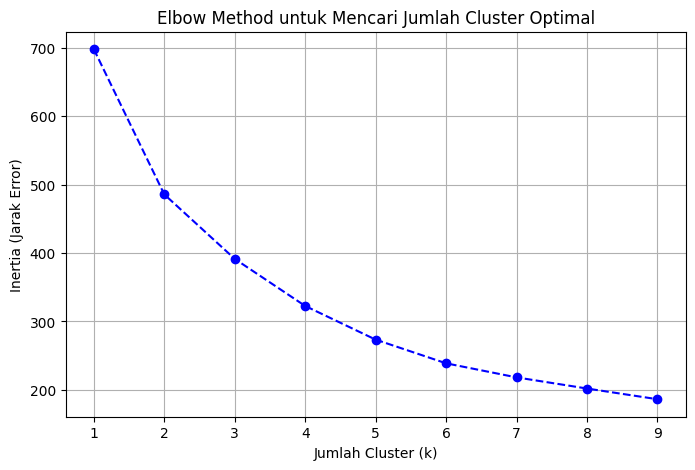

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method untuk Mencari Jumlah Cluster Optimal')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia (Jarak Error)')
plt.grid(True)
plt.show()

Terlihat bahwa titik siku (elbow) berada di angka $k=3$. Penurunan nilai Inertia (Jarak Error) sangat tajam dari cluster 1 ke 3, namun mulai melandai secara stagnan pada cluster ke-4 dan seterusnya. Dapat diambil membagi dalam 3 cluster itu pilihan yang pas.

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_keuangan['cluster_investor'] = kmeans.fit_predict(x_scaled)

In [ ]:
sil_score = silhouette_score(x_scaled, df_keuangan['cluster_investor'])

In [ ]:
print(f"Silhouette Score model: {sil_score:.3f}")

Silhouette Score model: 0.261


In [ ]:
profiling_cols = [col for col in kolom_cluster if col != 'user_id']
profil_cluster = df_keuangan.groupby('cluster_investor')[profiling_cols].mean().round(2)
display(profil_cluster)

,investment_amount,debt_to_income_ratio,score_emergency
cluster_investor,,,
0,10498346.85,0.25,2.48
1,6967562.86,0.49,2.33
2,3502186.46,0.25,2.26


In [ ]:
kamus_cluster = {
    0: 'Siap Investasi (Agresif)',
    1: 'Belum Siap Investasi',
    2: 'Siap Investasi (Konservatif)'
}

Kamus untuk keterangan setiap label cluster (0,1,2)

In [ ]:
df_keuangan['status_kesiapan_invest'] = df_keuangan['cluster_investor'].map(kamus_cluster)

In [ ]:
df_keuangan.head(339)

,date,user_id,monthly_income,monthly_expense_total,emergency_fund,investment_amount,debt_to_income_ratio,age,Rasio Dana Darurat,score_emergency,cluster_investor,status_kesiapan_invest
0,2019-01-01,1584,54524019.24,56140559.46,8923917.24,12046187.16,0.56,24,0.16,1.07,1,Belum Siap Investasi
1,2019-01-31,1045,57020926.32,65242053.18,20176777.98,6298022.52,0.42,21,0.31,2.07,1,Belum Siap Investasi
2,2019-03-02,1756,51231513.60,58299267.24,25046323.56,0.00,0.24,30,0.43,2.87,2,Siap Investasi (Konservatif)
3,2019-04-01,1724,61291675.62,40681618.02,3973972.86,3182044.68,0.16,28,0.10,0.67,2,Siap Investasi (Konservatif)
4,2019-05-01,1600,80518873.86,38147133.24,10308699.18,5991108.84,0.25,25,0.27,1.80,2,Siap Investasi (Konservatif)
...,...,...,...,...,...,...,...,...,...,...,...,...
334,2021-10-17,1279,62061756.30,45582449.22,6726932.64,196627.50,0.39,26,0.15,1.00,2,Siap Investasi (Konservatif)
335,2021-11-16,1424,59540729.58,32839064.64,13486024.80,12551126.58,0.38,20,0.41,2.73,0,Siap Investasi (Agresif)
336,2021-12-16,1853,60518973.24,52738291.98,10337188.32,5297407.02,0.42,26,0.20,1.33,1,Belum Siap Investasi
337,2022-01-15,1199,63968955.66,48960597.06,19390442.76,5363124.30,0.10,30,0.40,2.67,2,Siap Investasi (Konservatif)


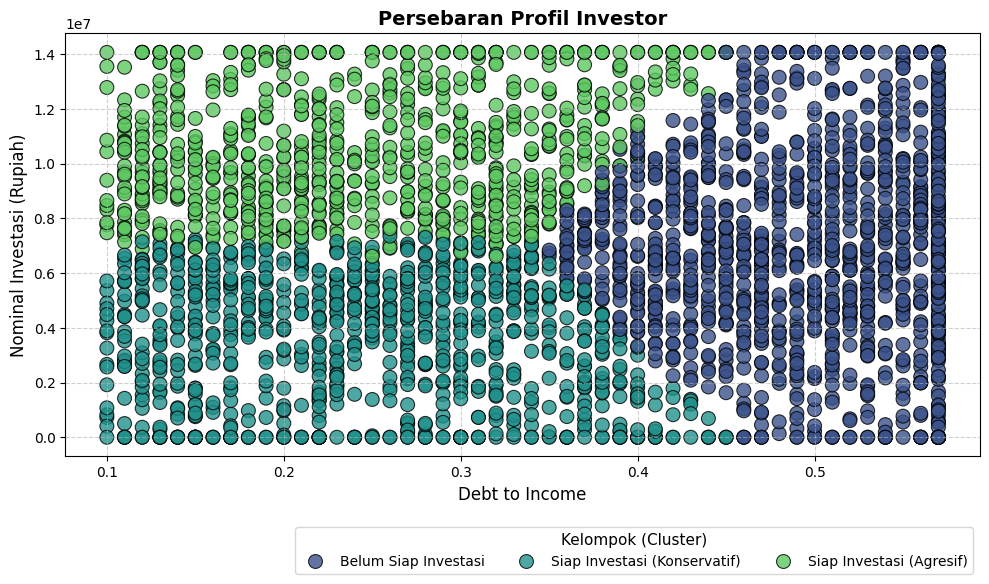

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_keuangan,
    x='debt_to_income_ratio',   # Sumbu X: Rasio utang (0 sampai 1)
    y='investment_amount',      # Sumbu Y: Uang yang diinvestasikan
    hue='status_kesiapan_invest',
    palette='viridis',
    s=100,
    alpha=0.8,
    edgecolor='black'
)


plt.title('Persebaran Profil Investor', fontsize=14, fontweight='bold')
plt.xlabel('Debt to Income', fontsize=12)
plt.ylabel('Nominal Investasi (Rupiah)', fontsize=12)

#  garis bantu (grid)
plt.grid(True, linestyle='--', alpha=0.6)

plt.legend(
    title='Kelompok (Cluster)',
    title_fontsize='11',
    loc='upper right',
    bbox_to_anchor=(1, -0.15),
    ncol=3
)

plt.tight_layout()
plt.show()

#MERGE Data Kepemilikan Saham

In [ ]:
df_saham = pd.read_csv('lq45_clean_dataset.csv')

Meload dataset lq45 yang sudah clean untuk digabung pada dataset keuangan ini, sebagai kepemilikan saham masing masing user

In [ ]:
daftar_saham = df_saham['Ticker'].unique()

In [ ]:
jumlah_user = len(df_keuangan)

In [ ]:
np.random.seed(42)

In [ ]:
df_final = df_keuangan.copy()

In [ ]:
df_final['ticker_saham'] = 'Belum Ada Portfolio'
df_final['jumlah_lot'] = 0
df_final['average_price'] = 0

In [ ]:
mask_punya_uang = df_final['investment_amount'] > 0
jumlah_investor = mask_punya_uang.sum()

In [ ]:
df_final.loc[mask_punya_uang, 'ticker_saham'] = np.random.choice(daftar_saham, jumlah_investor)
df_final.loc[mask_punya_uang, 'jumlah_lot'] = np.random.randint(1, 50, jumlah_investor)
df_final.loc[mask_punya_uang, 'average_price'] = np.random.randint(1000, 5000, jumlah_investor)

In [ ]:
kolom_tampilan = ['investment_amount', 'Cluster_AI', 'ticker_saham', 'jumlah_lot']

In [ ]:
df_final.head(200)

,date,user_id,monthly_income,monthly_expense_total,emergency_fund,investment_amount,debt_to_income_ratio,age,Rasio Dana Darurat,score_emergency,cluster_investor,status_kesiapan_invest,ticker_saham,jumlah_lot,average_price
0,2019-01-01,1584,54524019.24,56140559.46,8923917.24,12046187.16,0.56,24,0.16,1.07,1,Belum Siap Investasi,MBMA.JK,41,3395
1,2019-01-31,1045,57020926.32,65242053.18,20176777.98,6298022.52,0.42,21,0.31,2.07,1,Belum Siap Investasi,SMGR.JK,25,1670
2,2019-03-02,1756,51231513.60,58299267.24,25046323.56,0.00,0.24,30,0.43,2.87,2,Siap Investasi (Konservatif),Belum Ada Portfolio,0,0
3,2019-04-01,1724,61291675.62,40681618.02,3973972.86,3182044.68,0.16,28,0.10,0.67,2,Siap Investasi (Konservatif),INDF.JK,48,4195
4,2019-05-01,1600,80518873.86,38147133.24,10308699.18,5991108.84,0.25,25,0.27,1.80,2,Siap Investasi (Konservatif),BRIS.JK,13,2505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2020-03-26,1749,86697172.08,62317634.22,23617846.62,7620932.34,0.57,29,0.38,2.53,1,Belum Siap Investasi,HRUM.JK,33,1350
196,2020-04-25,1244,62558655.84,62308196.10,19842598.62,10187052.30,0.55,26,0.32,2.13,1,Belum Siap Investasi,TINS.JK,21,4726
197,2020-05-25,1852,73325802.96,79141782.24,4312521.72,7621806.24,0.43,24,0.05,0.33,1,Belum Siap Investasi,BMRI.JK,17,4471
198,2020-06-24,1353,67488325.74,40476251.52,13056590.34,12405360.06,0.29,18,0.32,2.13,0,Siap Investasi (Agresif),MBMA.JK,22,3300


In [ ]:
df_final.to_csv('dataset_keuangan.csv', index=False)

Dataset Keuangan yang final telah siap

#EDA dan Explanatory Analysis

- Dari seluruh user bagaimana proposi dari setiap cluster?
- bagaimana karakterisitik finansial masing masing cluster?
- pakah orang yang gajinya besar (monthly_income) pasti investasinya (investment_amount) besar juga?

/tmp/ipykernel_8511/3987480288.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


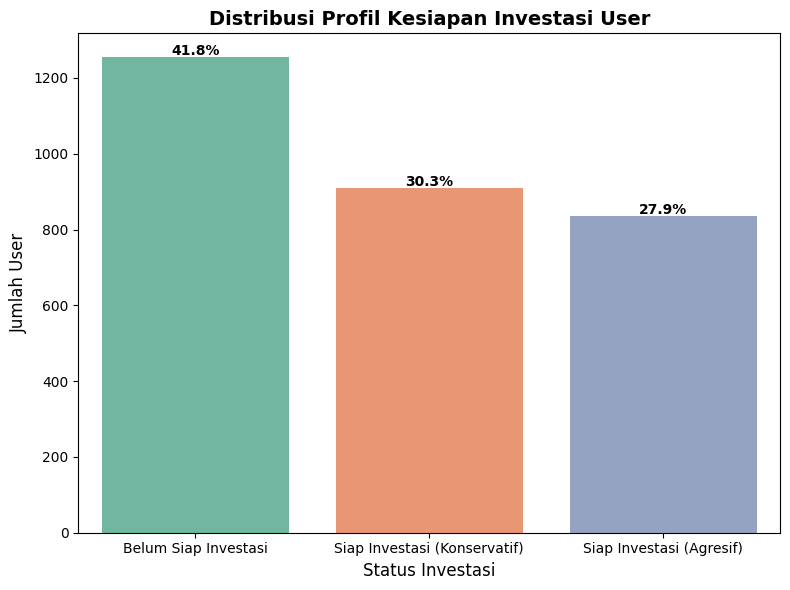

In [ ]:
# proporsi kesiapan investasi
plt.figure(figsize=(8, 6))
# jumlah user di tiap cluster
ax = sns.countplot(
    data=df_keuangan,
    x='status_kesiapan_invest',
    palette='Set2',
    order=df_keuangan['status_kesiapan_invest'].value_counts().index
)

total = len(df_keuangan)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x_pos = p.get_x() + p.get_width() / 2
    y_pos = p.get_height() + 5
    ax.annotate(percentage, (x_pos, y_pos), ha='center', fontweight='bold')

plt.title('Distribusi Profil Kesiapan Investasi User', fontsize=14, fontweight='bold')
plt.xlabel('Status Investasi', fontsize=12)
plt.ylabel('Jumlah User', fontsize=12)
plt.tight_layout()
plt.show()

kategori "Belum Siap Investasi" sebanyak (41.8%). Sementara itu, pengguna yang sudah siap berinvestasi terbagi menjadi dua profil risiko, yaitu "Konservatif" (30.3%) dan "Agresif" (27.9%). Meskipun kelompok "Belum Siap" adalah mayoritas tunggal, jika digabungkan, lebih dari separuh user kita (58.2%) sebenarnya sudah memiliki kapasitas untuk berinvestasi.

/tmp/ipykernel_8511/4067490420.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_8511/4067490420.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_8511/4067490420.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


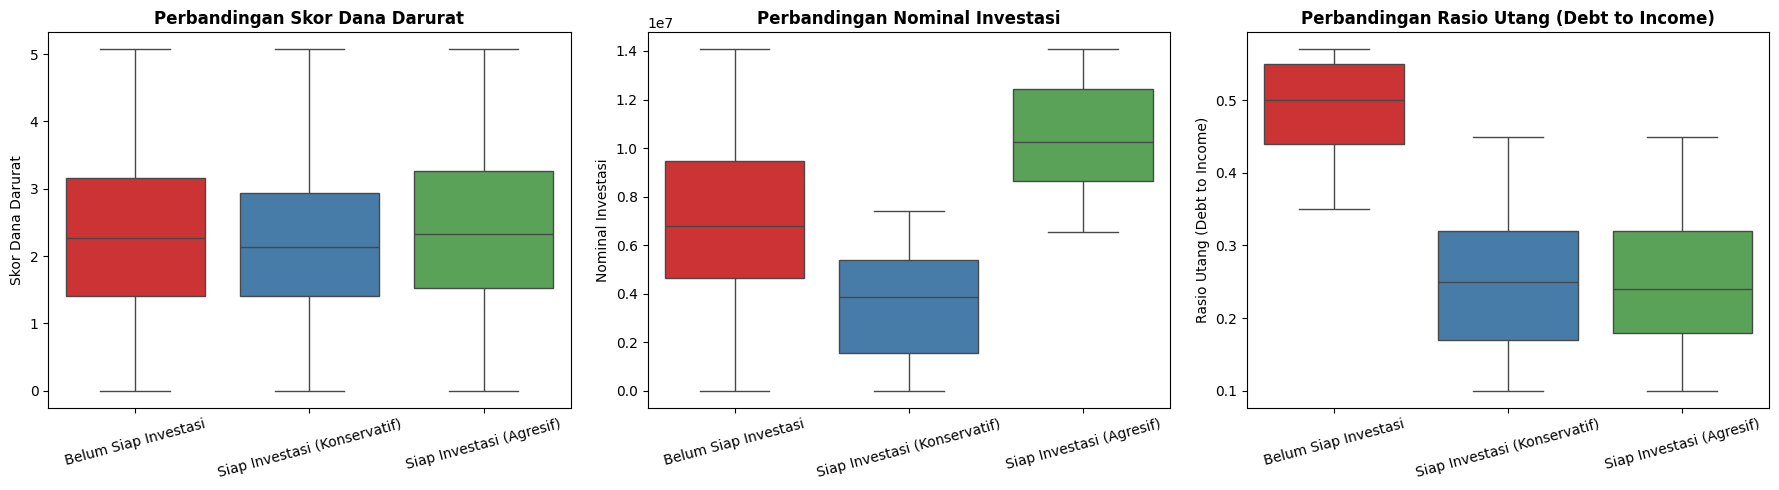

In [ ]:
# karakteristik tiap cluster
kolom_analisis = ['score_emergency', 'investment_amount', 'debt_to_income_ratio']
judul_analisis = ['Skor Dana Darurat', 'Nominal Investasi', 'Rasio Utang (Debt to Income)']

plt.figure(figsize=(18, 5))

for i, col in enumerate(kolom_analisis):
    plt.subplot(1, 3, i+1)
    sns.boxplot(
        data=df_keuangan,
        x='status_kesiapan_invest',
        y=col,
        palette='Set1'
    )
    plt.title(f'Perbandingan {judul_analisis[i]}', fontweight='bold')
    plt.xlabel('')
    plt.ylabel(judul_analisis[i])
    plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

Algoritma K-Means berhasil memisahkan profil user dalam 3 cluster :
- pertama di grafik perbandingan skor dana darurat, K-Means mendeteksi orang-orang yang rentan untuk berinvestasi dari keminimannya dana darurat artinya sangat tidak aman user tersebut untuk melakukan investasi.
- kedua di grafik perbandingan nominal investasi, median user berada di posisi tertinggi, membuktikan user cluster ini berani menaruh modal paling besar. dan juga badan kotaknya sangat lebar, artinya rentang modal di kelompok ini sangat bervariasi, mulai dari investor kelas menengah hingga investor yang sudah berpengalaman.
- ketiga di grafik perbandingan rasio utang, cluster yang belum siap investasi cenderung memiliki rasio utang yang lebih tinggi, dan cluster investor konservatif dan agresif memilki rasio utang yang rendah, tapi juga kita bisa lihat investor agresif memilki rasio utang yang lebih tinggi pada batas minimal dibandingkan dengan investor konservatif.

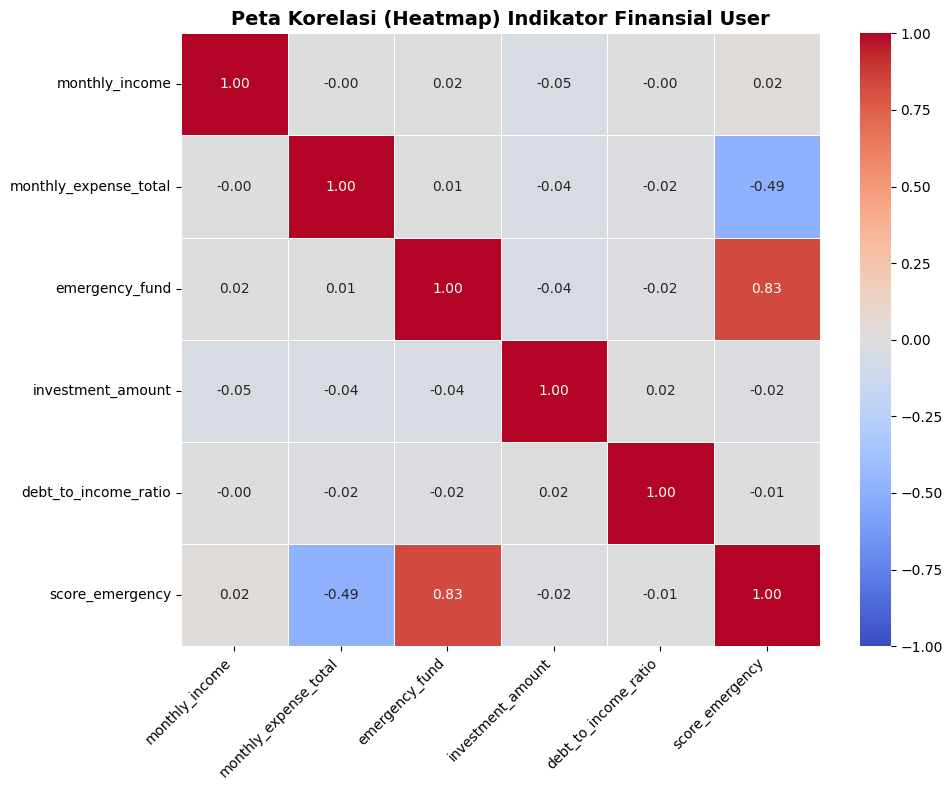

In [ ]:
# korelasi antar fitur
plt.figure(figsize=(10, 8))

kolom_numerik = [
    'monthly_income', 'monthly_expense_total', 'emergency_fund',
    'investment_amount', 'debt_to_income_ratio', 'score_emergency'
]

# Menghitung korelasi Pearson
matriks_korelasi = df_final[kolom_numerik].corr()

sns.heatmap(
    matriks_korelasi,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1
)

plt.title('Peta Korelasi (Heatmap) Indikator Finansial User', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- korelasi 'score emergency' dengan 'emergency fund' : dengan korelasi pearson (0.83), artinya semakin besar tabungan dana darurat (emergency fund) seseorang, maka skor keamanannya akan ikut naik.
- korelasi 'score emergency' dengan 'monthly_expense_total' : dengan korelasi pearson (-.49), artinya semakin boros pengeluaran bulanan seseorang maka skor keamanannya akan turun. Dan juga membuktikan rumus rasio (Tabungan / (Pengeluaran x 6)) untuk membagi cluster berjalan sempurna.
- korelasi 'monthly_income' dengan 'invest_amount' (-0,05) : berati user yang bergaji besar tidak menjamin akan berinvestasi dengan jumlah yang besar.
- korelasi 'monthly_income' dengan 'monthly_expanse_total' (-0.00): artinya tidak ada pola user yang bergaji tinggi memilki pengeluaran perbulan yang boros.